# Understanding Saliency Maps in Deep Learning
This Jupyter Notebook discusses how neural networks interpret images using gradient-based attribution methods

The notebook will cover the following:

- Input gradients (vanilla saliency)
- Guided backpropogation
- SmoothGrad
- How noise and gradients affect interpretability

The goal of this notebook is not just to show the implementation of these methods but to understand *why these methods behave the way they do*.

In [1]:
## The following Python packages will be used throughout this Jupyter Notebook
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

## Step 1: Loading the Pretrained Model

This step involves loading ResNet18; we’re using the version pretrained on ImageNet to leverage its learned features. This model allows the ability to see how a real deep learning model "sees" images.

In [2]:
## The ResNet18 model is defined and loaded below:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Step 2: Image Preprocessing

The images that will be used in the model were resized and converted into tensors which the neural network can understand.

In [3]:
## The transforms.Compose() method was used to resize image and convert it into tensors for the network to understand
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def preprocess(image):
    return transform(image).unsqueeze(0)

## Step 3: Input Image

A sample image will be used to observe how gradients highlight important regions.

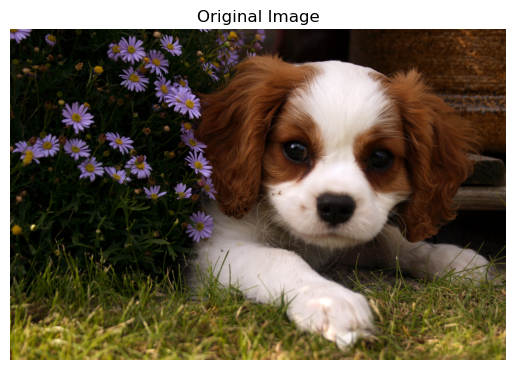

In [4]:
## The image was loaded and preprocessed
image = Image.open("dog.jpg").convert("RGB")
input_tensor = preprocess(image)

## Here we are displaying the image
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

## Step 4: Vanilla Saliency (Input Gradients)

We compute the gradients of the output with respect to the input image. This will inform us which pixels most influence the prediction

In [5]:
def vanilla_saliency(input_tensor):
    ## A copy of the input tensor is created and detached from any previous computation graph. Gradient tracking is enabled so that the gradients are
    ## calculated with respect to the input pixels
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    ## Any previously stored gradients in the model were removed
    model.zero_grad()
    ## A forward pass through the model is performed to get predictions
    output = model(input_tensor)
    ## The highest prediction score (the class the model is most confident about) is selected
    score = output.max()
    ## Backpropogation was performed using the score.backward() method. This will calculate the gradients of the selected score 
    ## with respect to the input image pixels
    score.backward()
    ## The absolute values of the gradients were taken since positive and negative gradients can represent importance
    ## Any unneccessary dimensions were removed through the squeeze () method and the tensor is converted to a NumPy array for easier processing
    saliency = input_tensor.grad.abs().squeeze().numpy()
    ## If the input has multiple channels, the maximum gradient is taken across channels for each pixel. This will produce a 2D saliency map
    saliency = np.max(saliency, axis=0)

    return saliency

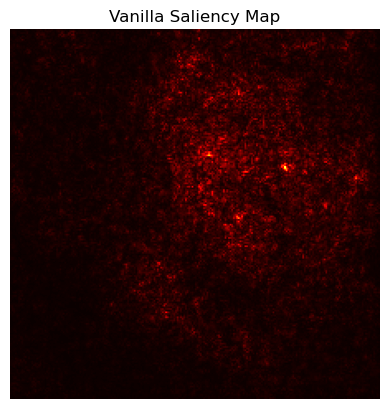

In [6]:
saliency = vanilla_saliency(input_tensor)

plt.imshow(saliency, cmap="hot")
plt.title("Vanilla Saliency Map")
plt.axis("off")
plt.show()

## Observation
Through this, we can observe that vanilla saliency maps are often noisy, unstable and hard to predict. When small changes are made to the input,
the gradients that are calculated can drastically change

## Step 5: Guided Backpropogation

Guided Backpropogation alters standard gradients by blocking negative gradients during backpropagation.
This makes the visualization sharper by only allowing features that *positively contribute* to the prediction.

In [7]:
def guided_backprop(input_tensor):
    ## The model was set to evaluation mode to disable any training-specific layers
    model.eval()
    ## This is a custom method that was used to define a backward hook for the ReLU layers
    def relu_hook(module, grad_in, grad_out):
        ## During backpropagation, the negative gradients are set to 0 to only allow positive gradients to pass backward
        ## Guided Backprop modifies the standard backprop as follows:
        return (torch.clamp(grad_in[0], min=0.0),)

    ## All registered hooks are stored in this array
    hooks = []

    ## We are looping through all of the modules in the model
    for module in model.modules():
        ## Find every ReLU activation layer
        if isinstance(module, torch.nn.ReLU):
            ## Attach the custom backward hook to modify the gradient flow
            hooks.append(module.register_backward_hook(relu_hook))

    ## A copy of the input tensor is created and detached from any previous computation graph. Gradient tracking is enabled so that the gradients are
    ## calculated with respect to the input pixels
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    ## Any previously stored gradients in the model were removed
    model.zero_grad()
    ## A forward pass through the model is performed to get predictions
    output = model(input_tensor)
    ## The highest prediction score (the class the model is most confident about) is selected
    score = output.max()
    ## Backpropogation was performed using the score.backward() method. This will calculate the gradients of the selected score 
    ## with respect to the input image pixels
    score.backward()
    ## The absolute values of the gradients were taken since positive and negative gradients can represent importance
    ## Any unneccessary dimensions were removed through the squeeze () method and the tensor is converted to a NumPy array for easier processing
    saliency = input_tensor.grad.abs().squeeze().numpy()
    ## If the input has multiple channels, the maximum gradient is taken across channels for each pixel. This will produce a 2D saliency map
    saliency = np.max(saliency, axis=0)
    ## All of the hooks were removed to avoid impacting further computation
    for h in hooks:
        h.remove()

    return saliency

C:\Users\renzo\anaconda3\envs\python310\lib\site-packages\torch\nn\modules\module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


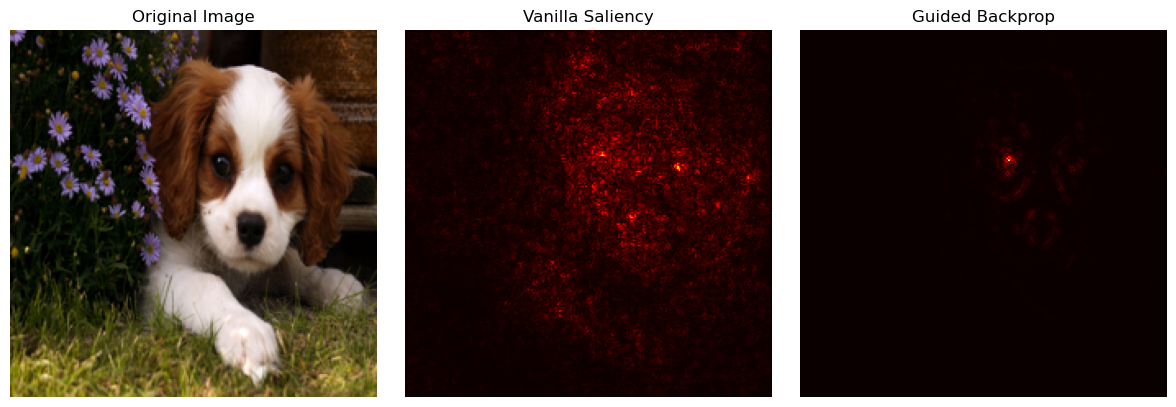

In [8]:
## The map was normalized using this function
def normalize_map(saliency):
    saliency -= saliency.min()
    saliency /= (saliency.max() + 1e-8)
    return saliency
def visualize_guided_backprop(input_tensor, image):
    # Compute saliency maps
    vanilla = normalize_map(vanilla_saliency(input_tensor))
    guided = normalize_map(guided_backprop(input_tensor))

    # Convert original image for display
    image_resized = image.resize((224, 224))

    plt.figure(figsize=(12,4))

    # Original image
    plt.subplot(1,3,1)
    plt.imshow(image_resized)
    plt.title("Original Image")
    plt.axis("off")

    # Vanilla Saliency
    plt.subplot(1,3,2)
    plt.imshow(vanilla, cmap="hot")
    plt.title("Vanilla Saliency")
    plt.axis("off")

    # Guided Backprop
    plt.subplot(1,3,3)
    plt.imshow(guided, cmap="hot")
    plt.title("Guided Backprop")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
visualize_guided_backprop(input_tensor, image)

## Step 6: SmoothGrad

The SmoothGrad technique is used to improve saliency by adding noise multiple times and averaging results.

This reduces visual noise and highlights consistent features.

In [9]:
def smoothgrad(input_tensor, n_samples=20, noise_level=0.1):
    ## A tensor was created to be able to gather gradients from multiple noisy samples. This has the same shape as the input image
    total_grad = torch.zeros_like(input_tensor)

    ## This loop is repeated multiple times whilst adding different levels of noise
    for _ in range(n_samples):
        ## Random Gaussian noise is generated. The noise level controls how strong the perturbation is
        noise = torch.randn_like(input_tensor) * noise_level
        ## Noise is added to the input image. It is then detached from previous graph and gradient tracking is enabled
        noisy_input = (input_tensor + noise).detach().requires_grad_(True)
        ## Any previously stored gradients in the model were removed
        model.zero_grad()
        ## A forward pass through the model is performed to get predictions
        output = model(noisy_input)
        ## The highest prediction score (the class the model is most confident about) is selected
        score = output.max()
        ## Backpropogation was performed using the score.backward() method. This will calculate the gradients of the selected score 
        ## with respect to the input image pixels
        score.backward()
        ## The absolute gradient values are accumulated to show pixel importance
        total_grad += noisy_input.grad.abs()
    ## The average gradients across all of the samples is calculated to reduce noise in the saliency map
    saliency = total_grad / n_samples
    ## Any unneccessary dimensions were removed through the squeeze () method and the tensor is converted to a NumPy array for easier processing
    saliency = saliency.squeeze().numpy()
    ## If the input has multiple channels, the maximum gradient is taken across channels for each pixel. This will produce a 2D saliency map
    saliency = np.max(saliency, axis=0)

    return saliency

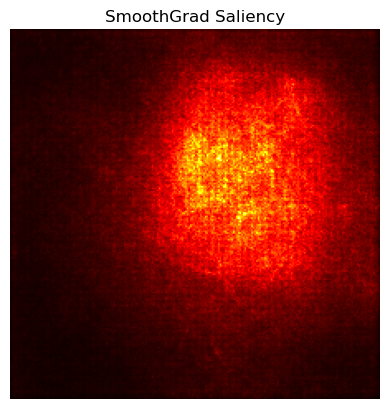

In [10]:
smooth = smoothgrad(input_tensor, n_samples=30, noise_level=0.2)

plt.imshow(smooth, cmap="hot")
plt.title("SmoothGrad Saliency")
plt.axis("off")
plt.show()

## Step 7: Effects of Noise Level

Testing was performed using different noise levels to see how noise affects the results of the SmoothGrad method

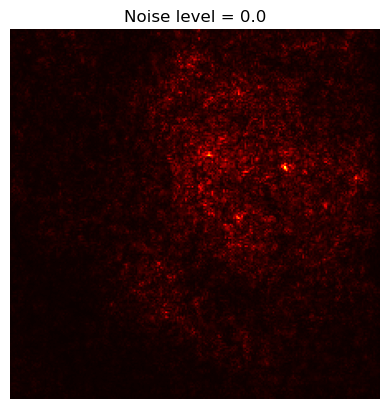

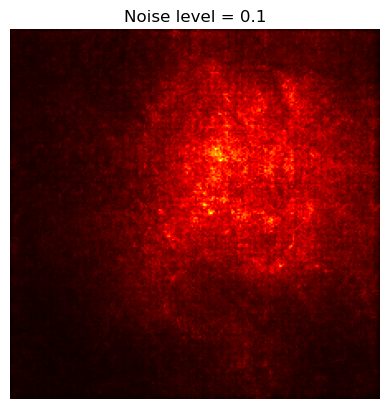

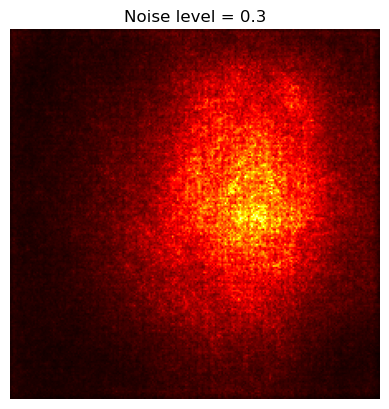

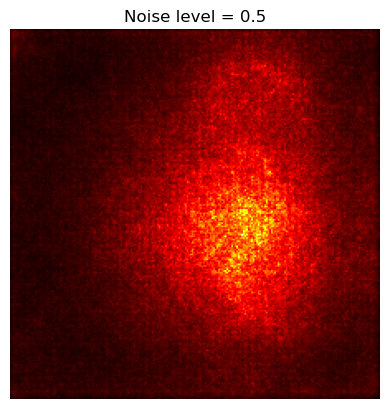

In [11]:
for noise in [0.0, 0.1, 0.3, 0.5]:
    result = smoothgrad(input_tensor, n_samples=20, noise_level=noise)

    plt.figure()
    plt.imshow(result, cmap="hot")
    plt.title(f"Noise level = {noise}")
    plt.axis("off")
    plt.show()

## SmoothGrad Noise Averaging Process

This visualization shows how adding noise gradually stabilizes saliency maps.

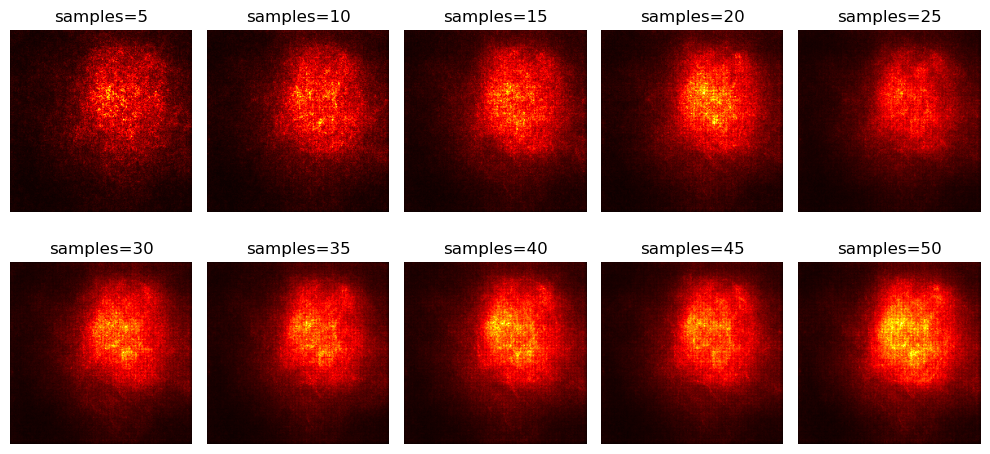

In [12]:
def smoothgrad_frames(input_tensor, steps=10):
    frames = []

    for i in range(1, steps+1):
        sal = smoothgrad(input_tensor, n_samples=i*5, noise_level=0.2)
        sal = normalize_map(sal)
        frames.append(sal)

    return frames
frames = smoothgrad_frames(input_tensor)

plt.figure(figsize=(10,5))

for i, frame in enumerate(frames):
    plt.subplot(2,5,i+1)
    plt.imshow(frame, cmap="hot")
    plt.title(f"samples={ (i+1)*5 }")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 8: Comparison of Interpretability Methods

We now compare three approaches side-by-side:
- Vanilla Saliency
- Guided Backpropagation
- SmoothGrad

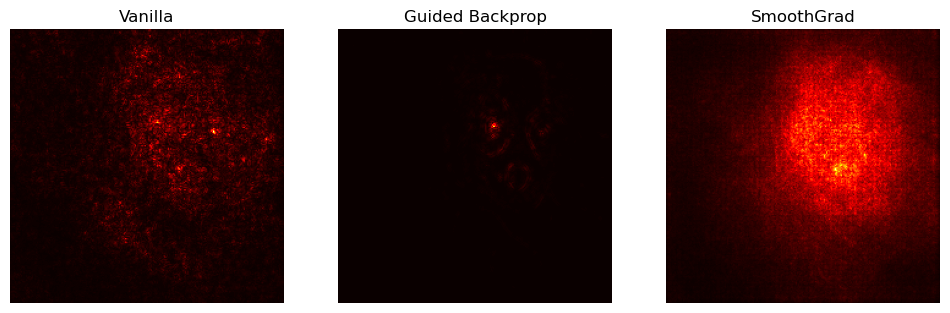

In [13]:
def show_grid(image, input_tensor):
    vanilla = normalize_map(vanilla_saliency(input_tensor))
    guided = normalize_map(guided_backprop(input_tensor))
    smooth = normalize_map(smoothgrad(input_tensor, 20, 0.2))

    images = [vanilla, guided, smooth]
    titles = ["Vanilla", "Guided Backprop", "SmoothGrad"]

    plt.figure(figsize=(12,4))

    for i in range(3):
        plt.subplot(1,3,i+1)
        plt.imshow(images[i], cmap="hot")
        plt.title(titles[i])
        plt.axis("off")

    plt.show()
show_grid(image, input_tensor)

## Key Insight

Through this, we can deduce the following:

- The Vanilla saliency approach is sensitive but noisy
- The SmoothGrad approach is stable and interpretable
- Noise acts as a “smoothing filter” over gradients

This shows that interpretability methods are highly dependent on design choices.

## Failure Modes of Saliency Methods

Saliency maps do NOT always reflect true reasoning.

They can:
- focus on background instead of object
- be insensitive to model changes
- produce visually convincing but misleading explanations

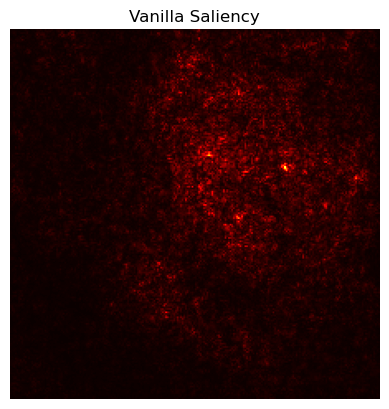

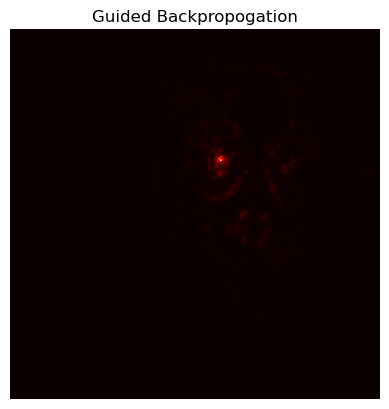

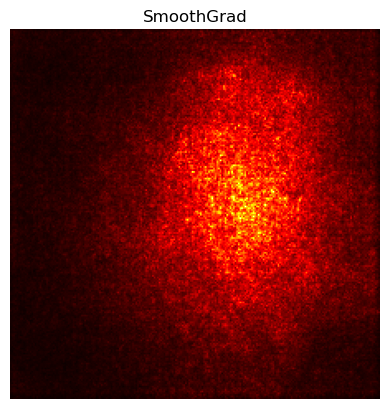

In [14]:
def show_failure_modes(input_tensor):
    plt.title("Vanilla Saliency")
    v = normalize_map(vanilla_saliency(input_tensor))
    plt.imshow(v, cmap="hot")
    plt.axis("off")
    plt.show()

    plt.title("Guided Backpropogation")
    g = normalize_map(guided_backprop(input_tensor))
    plt.imshow(g, cmap="hot")
    plt.axis("off")
    plt.show()

    plt.title("SmoothGrad")
    s = normalize_map(smoothgrad(input_tensor, 10, 0.3))
    plt.imshow(s, cmap="hot")
    plt.axis("off")
    plt.show()
show_failure_modes(input_tensor)

## Real World Applications

Saliency Maps can be used in:

- medical imaging (tumour detection explanations)
- autonomous driving systems
- debugging deep learning models
- bias detection in datasets